In [15]:
import pandas as pd
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (2)\train.csv")
print(df.head())

   id customer_state  customer_account_duration customer_area_code  \
0   1             MN                      117.0                408   
1   2             NH                       78.0      area_code_408   
2   3             RI                       89.0                415   
3   4             PA                       84.0      area_code_415   
4   5             OR                        NaN      area_code_408   

  has_international_plan has_voice_mail_plan  voice_mail_message_count  \
0                    NaN                True                      21.0   
1                  False                True                      28.0   
2                     no                True                      24.0   
3                  false               False                       NaN   
4                  false               False                       0.0   

   daytime_total_minutes  daytime_total_calls  daytime_total_charges  ...  \
0                  538.3                112.0            

C:\Users\hp\AppData\Local\Temp\ipykernel_3984\2200817199.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


Accuracy : 0.7815126050420168
Precision : 0.2871287128712871
Recall : 0.3333333333333333
F1 Score : 0.30851063829787234
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       508
           1       0.29      0.33      0.31        87

    accuracy                           0.78       595
   macro avg       0.58      0.60      0.59       595
weighted avg       0.80      0.78      0.79       595



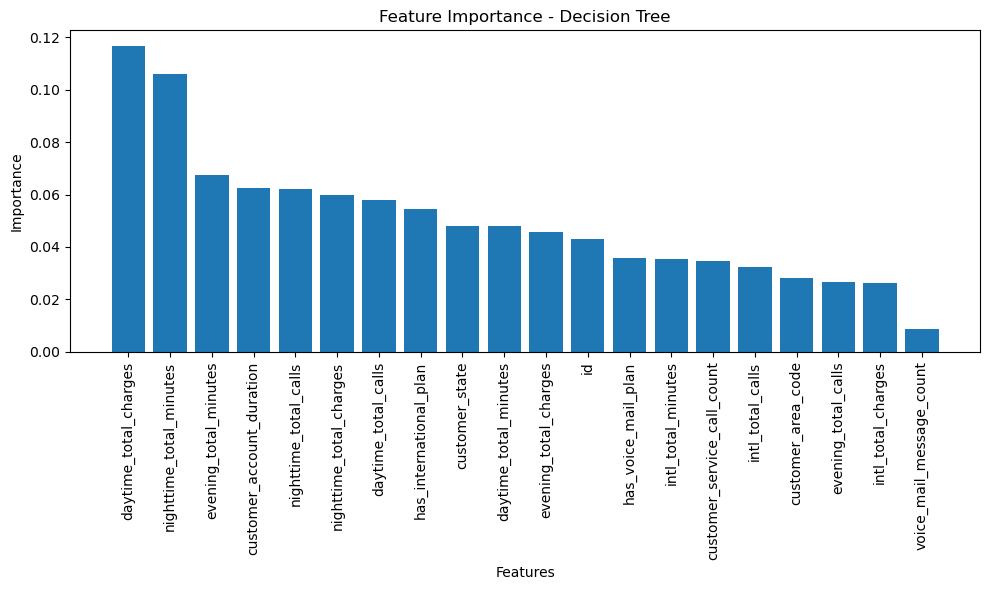

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (2)\train.csv")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
X = df.drop("churn", axis=1)
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)
print(classification_report(y_test, y_pred))
importance = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))
plt.bar(feature_df['Feature'], feature_df['Importance'])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Decision Tree")
plt.tight_layout()
plt.show()